<a href="https://colab.research.google.com/github/aaryanyaadav/Real-Time-Card-Not-Present-Fraud-Detection/blob/main/Real_Time_Card_Not_Present_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Real Time Card Not Found Fraud Detection

### Importing Libraries

In [1]:

!pip install -q opendatasets kaggle

In [2]:
import pandas as pd
import numpy as np
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Importing the Dataset

In [3]:

dataset_url = "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: aryaanyaadav
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:04<00:00, 17.2MB/s]


### EDA (Exploratory Data Analysis)




#### Creating a DataFrame


In [4]:
df = pd.read_csv("creditcardfraud/creditcard.csv")

In [5]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.Class.unique()

array([0, 1])

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#### Dataset Shape

In [9]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


#### Handeling the Duplicates

In [10]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 1081


In [11]:
df = df.drop_duplicates()

print(f"Dataset Shape after removing duplicates: {df.shape}")

Dataset Shape after removing duplicates: (283726, 31)


#### Handeling Missing Values

In [12]:
print(f"Total Missing Values: {df.isnull().sum().sum()}")

Total Missing Values: 0


#### Final Shape

In [13]:
print(f"Final Dataset Shape: {df.shape}")

Final Dataset Shape: (283726, 31)


#### Count Fraud vs Legitimate Transactions

In [14]:

class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


##### Class Imbalance

In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


##### Visualize Class Imbalance

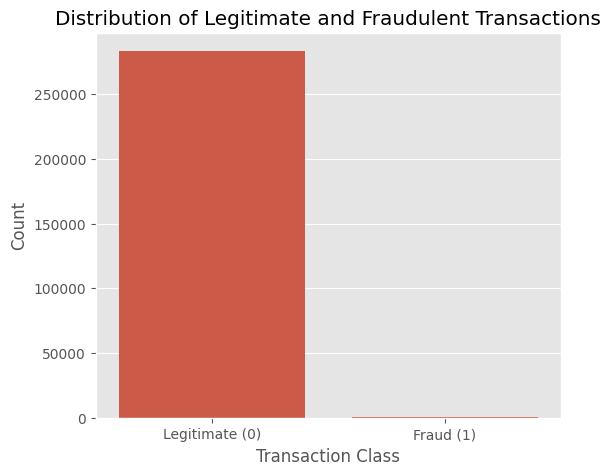

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.xticks([0,1],["Legitimate (0)","Fraud (1)"])

plt.show()

### Test-Train Split

##### Separate Features and Target

In [17]:
X = df.drop("Class", axis=1)
y = df["Class"]

##### Split the Dataset


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##### Verify the Split

In [19]:
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Label Shape   :", y_train.shape)
print("Testing Label Shape    :", y_test.shape)

Training Feature Shape : (226980, 30)
Testing Feature Shape  : (56746, 30)
Training Label Shape   : (226980,)
Testing Label Shape    : (56746,)


### Scaling the Dataset

##### Importing the Library

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:

scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)

In [23]:
X_test_scaled = scaler.transform(X_test)

##### Verify the shapes

In [24]:
print("Scaled Training Data Shape :", X_train_scaled.shape)
print("Scaled Testing Data Shape  :", X_test_scaled.shape)

Scaled Training Data Shape : (226980, 30)
Scaled Testing Data Shape  : (56746, 30)


##### Verify the Scaling

In [25]:
print("Mean of first feature :", X_train_scaled[:, 0].mean())
print("Standard Deviation of first feature :", X_train_scaled[:, 0].std())

Mean of first feature : -1.5188797928927686e-16
Standard Deviation of first feature : 1.0


### Baseline Model

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score
)

In [27]:
# Create the baseline Linear SVM model
linear_svm = SVC(
    kernel='linear',
    random_state=42
)

In [28]:
# Train the model
linear_svm.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [29]:
# Predict on the test data
y_pred_linear = linear_svm.predict(X_test_scaled)

##### Evaluate the Baseline model

In [30]:
accuracy = accuracy_score(y_test, y_pred_linear)
precision = precision_score(y_test, y_pred_linear)
recall = recall_score(y_test, y_pred_linear)
f1 = f1_score(y_test, y_pred_linear)
pr_auc = average_precision_score(y_test, y_pred_linear)

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Accuracy            : 0.9994
Precision           : 0.8659
Recall              : 0.7474
F1-Score            : 0.8023
Precision-Recall AUC: 0.6475


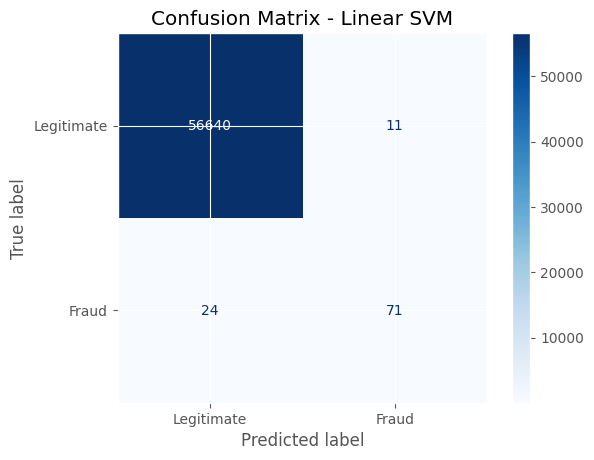

In [31]:
cm = confusion_matrix(y_test, y_pred_linear)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Linear SVM")

plt.show()

### Polynomial SVM

In [33]:
poly_svm = SVC(
    kernel='poly',
    degree=3,
    random_state=42
)

##### Train the Model

In [34]:
poly_svm.fit(X_train_scaled, y_train)

SVC(kernel='poly', random_state=42)

In [35]:

y_pred_poly = poly_svm.predict(X_test_scaled)

y_scores_poly = poly_svm.decision_function(X_test_scaled)

##### Evaluate the Model

In [36]:
accuracy = accuracy_score(y_test, y_pred_poly)
precision = precision_score(y_test, y_pred_poly)
recall = recall_score(y_test, y_pred_poly)
f1 = f1_score(y_test, y_pred_poly)
pr_auc = average_precision_score(y_test, y_scores_poly)

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Accuracy            : 0.9993
Precision           : 0.9265
Recall              : 0.6632
F1-Score            : 0.7730
Precision-Recall AUC: 0.7219


##### Confusion Matrix

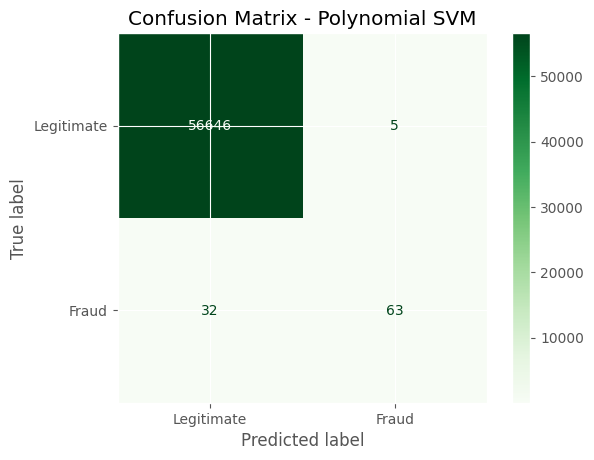

In [38]:
cm = confusion_matrix(y_test, y_pred_poly)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Polynomial SVM")

plt.show()

### RBF SVM Model

In [39]:
rbf_svm = SVC(
    kernel='rbf',
    random_state=42
)

In [ ]:
rbf_svm.fit(X_train_scaled, y_train)

##### Make Predictions

In [ ]:
y_pred_rbf = rbf_svm.predict(X_test_scaled)
y_scores_rbf = rbf_svm.decision_function(X_test_scaled)